## TPMS Hexagonal pincell with reflector

In [ ]:
import openmc
import math
from openmc import volume
from matplotlib import pyplot as plt
print(openmc.__version__)
from warnings import warn
import CoolProp.CoolProp as CP
import os

# Choose the algorithm: "brent", "bisection", "toms748", "newton"
os.environ["TPMS_SOLVER"] = "brent"
# Choose the root search mechanism: "derivatives" (--> original Ferney) or "subintervals" (-->new)
os.environ["TPMS_BRACKET"] = "subintervals"   
# Choose the number of subintervals you want in case you chose the "subintervals" method
os.environ["TPMS_N_SUBINTERVALS"]  = "2"  

0.15.3.dev82+gc40022633


In [11]:
# Remove existing OpenMC input XML files and output HDF5 files
!rm *.xml
!rm *.png
!rm -f summary.h5
!rm -f statepoint.*.h5
!rm *.h5
!rm -f *.xml
# Reset ID
openmc.reset_auto_ids()

rm: cannot remove '*.h5': No such file or directory


## Function definition - materials and bounding region for tpms

In [12]:
#### Create cubic box for unit cell analysis
def Box(c:float, boundary_type="transmission"):
    xP0 = openmc.XPlane(-c/2, boundary_type=boundary_type)
    xP1 = openmc.XPlane(+c/2, boundary_type=boundary_type)
    yP0 = openmc.YPlane(-c/2, boundary_type=boundary_type)
    yP1 = openmc.YPlane(+c/2, boundary_type=boundary_type)
    zP0 = openmc.ZPlane(-c/2, boundary_type=boundary_type)
    zP1 = openmc.ZPlane(+c/2, boundary_type=boundary_type)
    
    if boundary_type == "periodic":
        xP0.periodic_surface = xP1
        yP0.periodic_surface = yP1
        zP0.periodic_surface = zP1
    
    return +xP0 & (-xP1 & (+yP0 & (-yP1 & (+zP0 & -zP1))))

###############################################################################################################################
############################################# CYLINDERS #######################################################################
### Create Cylinder with height h and radius r.  Centered in z=0. 
def Cylinder(r: float, h: float):
    cyl  = openmc.ZCylinder(r=r)
    zP0  = openmc.ZPlane(-h/2)
    zP1  = openmc.ZPlane(+h/2)
    return -cyl & +zP0 & -zP1

### Cylinder used as top part of coolant (no tpms)
def Cylinder_upper(r: float, thickness: float, z_start: float):
    cyl = openmc.ZCylinder(r=r)
    z_bottom = openmc.ZPlane(z0=z_start)      # Contact plane
    z_top = openmc.ZPlane(z0=z_start + thickness, boundary_type="vacuum")
    return -cyl & +z_bottom & -z_top

### Cylinder used between the core and the upper tap
def Cylinder_upper_inner(r: float, thickness: float, z_start: float):
    cyl = openmc.ZCylinder(r=r)
    z_bottom = openmc.ZPlane(z0=z_start)      
    z_top = openmc.ZPlane(z0=z_start + thickness)
    return -cyl & +z_bottom & -z_top

### Cylinder used as bottom part of coolant (no tpms)
def Cylinder_bottom(r: float, thickness: float, z_start: float):
    cyl = openmc.ZCylinder(r=r)
    z_top = openmc.ZPlane(z0=z_start)  
    z_bottom = openmc.ZPlane(z0=z_start - thickness, boundary_type="vacuum")
    return -cyl & +z_bottom & -z_top

### Cylinder used between the core and the bottom tap
def Cylinder_bottom_inner(r: float, thickness: float, z_start: float):
    cyl = openmc.ZCylinder(r=r)
    z_top = openmc.ZPlane(z0=z_start)  
    z_bottom = openmc.ZPlane(z0=z_start - thickness)
    return -cyl & +z_bottom & -z_top

################################################################################################################################################
################################################ MATERIALS ###############################################################################
def wo_to_ao_uranium(w235: float) -> tuple[float, float, float]:
    #Converts weight fractions of U234/U235/U238 in atom fractions.
    #U234 weight fraction calculated with empirical formula: wo234 (%) = 0.0015 + 0.0058*enr + 0.000054*enr^2
    # Formula taken from OAK RIDGE report K/HS/593 cited in "Relationship between isotopic uranium activities and total uranium at various
    # uranium enrichments", T. L. Rucker, C. M. Johnson, Oak Ridge, 1988.

    enr = w235 * 100.0          # empirical formula accept percentage value of enrichment
    w234 = (0.0015 + 0.0058 * enr + 0.000054 * enr**2) / 100.0      # /100 to convert back to fraction
    w238 = 1.0 - w235 - w234

    A = {"U234": 234.0409, "U235": 235.0439, "U238": 238.0508}     # [g/mol]
    n234 = w234 / A["U234"]
    n235 = w235 / A["U235"]
    n238 = w238 / A["U238"]
    total = n234 + n235 + n238
    return n234/total, n235/total, n238/total

############## HALEU (19.75% enriched UO2)
def make_fuel(materials: openmc.Materials, mColors: dict) -> tuple[openmc.Material, openmc.Materials, dict]:
    mFuel = openmc.Material(0, "mFuel_HALEU", 1300.)
    mFuel.set_density('g/cm3', 10.50)
    ao234, ao235, ao238 = wo_to_ao_uranium(w235=0.1975)
    mFuel.add_nuclide("U234", ao234, percent_type="ao")
    mFuel.add_nuclide("U235", ao235, percent_type="ao")
    mFuel.add_nuclide("U238", ao238, percent_type="ao")
    mFuel.add_nuclide("O16",  0.99757 * 2, percent_type="ao")
    mFuel.add_nuclide("O17",  0.00038 * 2, percent_type="ao")
    mFuel.add_nuclide("O18",  0.00205 * 2, percent_type="ao")
    mColors[mFuel] = (208, 52, 52)
    materials.append(mFuel)
    return mFuel, materials, mColors

############## ZrC 
def make_clad(materials: openmc.Materials, mColors: dict) -> tuple[openmc.Material, openmc.Materials, dict]:
    mClad = openmc.Material(1, "mClad", 1000.)  
    mClad.set_density('g/cm3', 6.59)            
    # Natural zirconium
    mClad.add_nuclide("Zr90", 0.5145 / 2, percent_type="ao") 
    mClad.add_nuclide("Zr91", 0.1122 / 2, percent_type="ao")  
    mClad.add_nuclide("Zr92", 0.1715 / 2, percent_type="ao")  
    mClad.add_nuclide("Zr94", 0.1738 / 2, percent_type="ao")  
    mClad.add_nuclide("Zr96", 0.0280 / 2, percent_type="ao")  
    # Natural carbon
    mClad.add_nuclide("C12",  0.9893 / 2, percent_type="ao")  
    mClad.add_nuclide("C13",  0.0107 / 2, percent_type="ao")  
    materials.append(mClad)
    mColors[mClad] = (210, 180, 100)   
    return mClad, materials, mColors

############## Graphite C (nuclear graphite) no impurities
def make_mod(materials: openmc.Materials, mColors: dict) -> tuple[openmc.Material, openmc.Materials, dict]:
    mMod = openmc.Material(2, "mMod_graphite", 1000.)
    mMod.set_density('g/cm3', 1.82)                          
    mMod.add_nuclide("C12", 0.9893, percent_type="ao")
    mMod.add_nuclide("C13", 0.0107, percent_type="ao")
    mMod.add_s_alpha_beta("c_Graphite")
    materials.append(mMod)
    mColors[mMod] = (80, 80, 80)       
    return mMod, materials, mColors

'''
############## YH_1.85
def make_mod(materials: openmc.Materials, mColors: dict) -> tuple[openmc.Material, openmc.Materials, dict]:
    mMod = openmc.Material(2, "mMod_YH", 700.)
    mMod.set_density('g/cm3', 4.30)             
    mMod.add_nuclide("Y89",  1.000 / 2.85, percent_type="ao")
    mMod.add_nuclide("H1",   0.999885 * 1.85 / 2.85, percent_type="ao")
    mMod.add_nuclide("H2",   0.000115 * 1.85 / 2.85, percent_type="ao")
    mMod.add_s_alpha_beta("c_H_in_YH2") 
    materials.append(mMod)
    mColors[mMod] = (180, 120, 200)    
    return mMod, materials, mColors

############## BeO  
def make_mod(materials: openmc.Materials, mColors: dict) -> tuple[openmc.Material, openmc.Materials, dict]:
    mMod = openmc.Material(2, "mMod_BeO", 1000.)
    mMod.set_density('g/cm3', 3.01)            
    mMod.add_nuclide("Be9",  1.0 * 0.5, percent_type="ao")
    mMod.add_nuclide("O16",  0.99757 * 0.5, percent_type="ao")
    mMod.add_nuclide("O17",  0.00038 * 0.5, percent_type="ao")
    mMod.add_nuclide("O18",  0.00205 * 0.5, percent_type="ao")
    mMod.add_s_alpha_beta("c_Be_in_BeO")
    mMod.add_s_alpha_beta("c_O_in_BeO")
    materials.append(mMod)
    mColors[mMod] = (220, 220, 180)      # yellow
    return mMod, materials, mColors
'''

############## Helium 
def make_cool(materials: openmc.Materials, mColors: dict) -> tuple[openmc.Material, openmc.Materials, dict]:   
    rho = CP.PropsSI('D', 'T', 1000., 'P', 7e6, 'Helium')     # [kg/m³]  # ~7 MPa, 1000K 
    mCool = openmc.Material(3, "mCool", 1000.)                # HTGR outlet ~1000K
    mCool.set_density('g/cm3', rho)              
    mCool.add_nuclide("He4", 0.999999)        
    mCool.add_nuclide("He3", 0.000001)       
    materials.append(mCool)
    mColors[mCool] = (200, 230, 255)           # light blue
    return mCool, materials, mColors


In [13]:
materials = openmc.Materials()
mColors = {}
mFuel, materials, mColors = make_fuel(materials, mColors)
mClad, materials, mColors = make_clad(materials, mColors)
mCool, materials, mColors = make_cool(materials, mColors)
mMod, materials, mColors = make_mod(materials, mColors)
materials.export_to_xml()

In [14]:
# CROSS SECTION file indications
openmc.config['cross_sections'] = "/home/alessio_crosa/openmc_tpms/openmc-dev-alessio/openmc_xs/endfb-viii.0-hdf5/cross_sections.xml"

## Geometry and BCs

In [15]:
pitch     = 6         # [cm] TPMS pitch
radius    = 5.05      # [cm] outer radius of TPMS cylinder (including lateral clad)
height    = 156       # [cm]
t_fuel    = 0.51      # [cm]
t_clad    = 0.06      # [cm] external cladding cap thickness
t_gap     = 0.02      # [cm] external gap thickness
ref_thick = 22        # [cm] axial moderator extra thickness 
 
t_gap_tap = t_gap/1.5                #only used for the taps
t_clad_tap= t_clad/1.5               #only used for the taps
t_anulus  = 0.5     # [cm] coolant annulus between clad and moderator block
r_inner   = radius - t_clad_tap - t_gap_tap
r_inner_2 = radius - t_clad_tap
r_water_annulus = radius + t_anulus
h_core = height + 2*t_gap_tap + 2*t_clad_tap
h_total = h_core + 2*ref_thick                     # axial moderator height ---> total height

hex_apothem = 16
hex_edge    = hex_apothem / math.cos(math.radians(30))

# --------------------------------------------------------
# TPMS thickness-based definition
# --------------------------------------------------------
tpms_type = "Gyroid"

half_fuel = t_fuel/2          # [cm] half-thickness of fuel layer

# Surfaces defined by thickness — symmetric around zero isovalue
# Structure (from inside out): cool | clad | gap | fuel | gap | clad | cool
tpms_clad_inner = openmc.TPMS.from_thickness(tpms_type, -t_clad - t_gap - half_fuel, pitch=pitch)
tpms_gap_inner  = openmc.TPMS.from_thickness(tpms_type, -t_gap  - half_fuel, pitch=pitch)
tpms_fuel_inner = openmc.TPMS.from_thickness(tpms_type, -half_fuel, pitch=pitch)
tpms_fuel_outer = openmc.TPMS.from_thickness(tpms_type, +half_fuel, pitch=pitch)
tpms_gap_outer  = openmc.TPMS.from_thickness(tpms_type, +half_fuel  + t_gap, pitch=pitch)
tpms_clad_outer = openmc.TPMS.from_thickness(tpms_type, +half_fuel  + t_gap + t_clad, pitch=pitch)

# --------------------------------------------------------
# Cylindrical surfaces and Z planes
# --------------------------------------------------------
cyl_outer   = openmc.ZCylinder(r=radius)
cyl_inner   = openmc.ZCylinder(r=r_inner)
cyl_inner_2 = openmc.ZCylinder(r=r_inner_2)

z_bottom   = openmc.ZPlane(-h_core/2, boundary_type="transmission")
z_upper    = openmc.ZPlane(+h_core/2, boundary_type="transmission")
z_ext_band = +z_bottom & -z_upper
z_mod_bottom   = openmc.ZPlane(-h_total/2, boundary_type="vacuum")
z_mod_upper    = openmc.ZPlane(+h_total/2, boundary_type="vacuum")
z_ext_mod = +z_mod_bottom & -z_mod_upper

cyl_water_outer = openmc.ZCylinder(r=r_water_annulus)
hex_prism = openmc.model.HexagonalPrism(
    edge_length   = hex_edge,
    orientation   = 'x',
    boundary_type = 'periodic'
)

# --------------------------------------------------------
# Regions
# --------------------------------------------------------
region_tpms               = Cylinder(r_inner, height)
region_clad_annulus_inner = +cyl_inner   & -cyl_inner_2      & z_ext_band
region_clad_annulus_outer = +cyl_inner_2 & -cyl_outer        & z_ext_band
region_gap_upper          = Cylinder_upper_inner(r_inner, t_gap,  height/2)
region_clad_upper         = Cylinder_upper_inner(r_inner, t_clad, height/2 + t_gap)
region_gap_bottom         = Cylinder_bottom_inner(r_inner, t_gap,  -height/2)
region_clad_bottom        = Cylinder_bottom_inner(r_inner, t_clad, -height/2 - t_gap)
region_water_annulus      = +cyl_outer       & -cyl_water_outer & z_ext_band
region_graphite           = +cyl_water_outer & -hex_prism       & z_ext_mod
region_top_cool           = Cylinder_upper(r_water_annulus, ref_thick, h_core/2)
region_bottom_cool        = Cylinder_bottom(r_water_annulus, ref_thick, -h_core/2)

# --------------------------------------------------------
# Cells — TPMS core
# --------------------------------------------------------
cell_fuel  = openmc.Cell(0, "cFuel",  mFuel, region_tpms & +tpms_fuel_inner & -tpms_fuel_outer)
cell_clad1 = openmc.Cell(1, "cClad",  mClad, region_tpms & +tpms_clad_inner & -tpms_gap_inner)
cell_clad2 = openmc.Cell(2, "cClad",  mClad, region_tpms & +tpms_gap_outer  & -tpms_clad_outer)
cell_gap1  = openmc.Cell(3, "cGap",   None,  region_tpms & +tpms_gap_inner  & -tpms_fuel_inner)
cell_gap2  = openmc.Cell(4, "cGap",   None,  region_tpms & +tpms_fuel_outer & -tpms_gap_outer)
cell_cool  = openmc.Cell(5, "cCool",  mCool, region_tpms & (-tpms_clad_inner | +tpms_clad_outer))

# Cells — upper and bottom clad caps
cell_clad_upper  = openmc.Cell(6,  "cClad", mClad, region_clad_upper  & +tpms_clad_inner & -tpms_clad_outer)
cell_clad_bottom = openmc.Cell(7,  "cClad", mClad, region_clad_bottom & +tpms_clad_inner & -tpms_clad_outer)
cell_water_upper  = openmc.Cell(8,  "cCool", mCool, region_clad_upper  & (-tpms_clad_inner | +tpms_clad_outer))
cell_water_bottom = openmc.Cell(9,  "cCool", mCool, region_clad_bottom & (-tpms_clad_inner | +tpms_clad_outer))

# Cells — upper and bottom gap caps
cell_gap_upper_inner    = openmc.Cell(10, "cGap",  None,  region_gap_upper  & +tpms_gap_inner  & -tpms_gap_outer)
cell_gap_bottom_inner   = openmc.Cell(11, "cGap",  None,  region_gap_bottom & +tpms_gap_inner  & -tpms_gap_outer)
cell_clad1_upper_inner  = openmc.Cell(12, "cClad", mClad, region_gap_upper  & +tpms_clad_inner & -tpms_gap_inner)
cell_clad2_upper_inner  = openmc.Cell(13, "cClad", mClad, region_gap_upper  & +tpms_gap_outer  & -tpms_clad_outer)
cell_clad1_bottom_inner = openmc.Cell(14, "cClad", mClad, region_gap_bottom & +tpms_clad_inner & -tpms_gap_inner)
cell_clad2_bottom_inner = openmc.Cell(15, "cClad", mClad, region_gap_bottom & +tpms_gap_outer  & -tpms_clad_outer)
cell_water_upper_inner  = openmc.Cell(16, "cCool", mCool, region_gap_upper  & (-tpms_clad_inner | +tpms_clad_outer))
cell_water_bottom_inner = openmc.Cell(17, "cCool", mCool, region_gap_bottom & (-tpms_clad_inner | +tpms_clad_outer))

# Cells — innermost lateral annulus
cell_lateral_gap_inner   = openmc.Cell(18, "cGap",  None,  region_clad_annulus_inner & +tpms_gap_inner  & -tpms_gap_outer)
cell_lateral_clad1_inner = openmc.Cell(19, "cClad", mClad, region_clad_annulus_inner & +tpms_clad_inner & -tpms_gap_inner)
cell_lateral_clad2_inner = openmc.Cell(20, "cClad", mClad, region_clad_annulus_inner & +tpms_gap_outer  & -tpms_clad_outer)
cell_lateral_water_inner = openmc.Cell(21, "cCool", mCool, region_clad_annulus_inner & (-tpms_clad_inner | +tpms_clad_outer))

# Cells — outermost lateral annulus
cell_lateral_clad_outer  = openmc.Cell(22, "cClad", mClad, region_clad_annulus_outer & +tpms_clad_inner & -tpms_clad_outer)
cell_lateral_water_outer = openmc.Cell(23, "cCool", mCool, region_clad_annulus_outer & (-tpms_clad_inner | +tpms_clad_outer))

# Cells — external coolant annulus and graphite moderator
cell_water_annulus = openmc.Cell(40, "cCool", mCool, region_water_annulus)
cell_graphite      = openmc.Cell(41, "cGraphite",     mMod,  region_graphite)

# Cells — bottom and top coolant areas
cell_top_coolant    = openmc.Cell(42, "cCool", mCool, region_top_cool)
cell_bottom_coolant = openmc.Cell(43, "cCool", mCool,  region_bottom_cool)

# --------------------------------------------------------
# Universe and geometry
# --------------------------------------------------------
universe = openmc.Universe(0, "universe", [
    cell_fuel, cell_clad1, cell_clad2, cell_gap1, cell_gap2, cell_cool,
    cell_clad_upper, cell_clad_bottom, cell_water_upper, cell_water_bottom,
    cell_gap_upper_inner, cell_gap_bottom_inner,
    cell_clad1_upper_inner, cell_clad2_upper_inner,
    cell_clad1_bottom_inner, cell_clad2_bottom_inner,
    cell_water_upper_inner, cell_water_bottom_inner,
    cell_lateral_gap_inner, cell_lateral_clad1_inner,
    cell_lateral_clad2_inner, cell_lateral_water_inner,
    cell_lateral_clad_outer, cell_lateral_water_outer,
    cell_water_annulus, cell_graphite, cell_top_coolant, cell_bottom_coolant
])

root     = openmc.Cell(30, "root", universe, -hex_prism & z_ext_mod)
geometry = openmc.Geometry([root])
geometry.export_to_xml()


PLOT

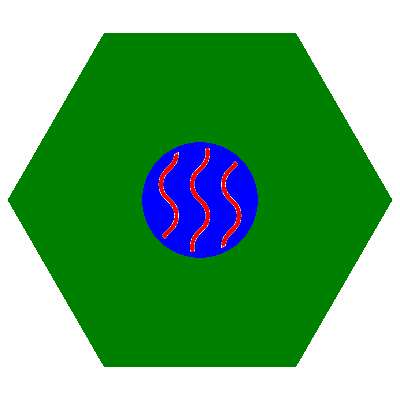

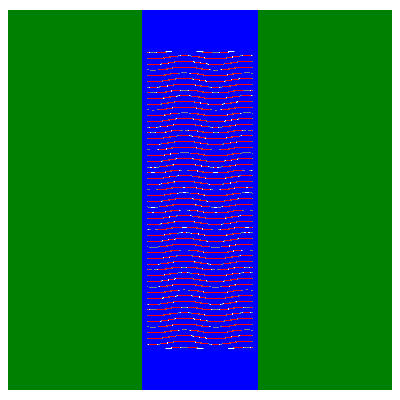

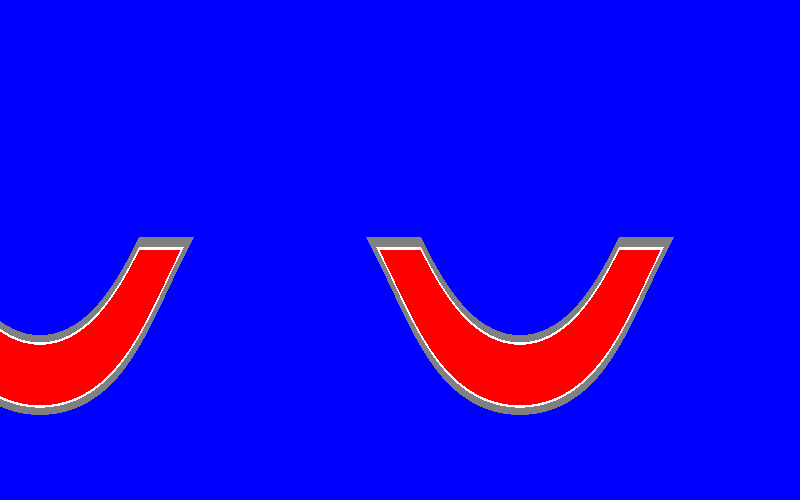

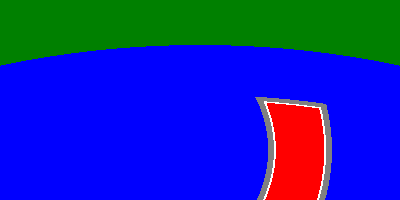

In [16]:
plot_xy = openmc.Plot()
plot_xy.basis = 'xy'
plot_xy.origin = (0, 0, 0)
plot_xy.width  = (2*hex_apothem*1.2, 2*hex_apothem*1.2)  
plot_xy.pixels = (400, 400)
plot_xy.color_by = 'material'
plot_xy.colors = {mFuel: 'red', mClad: 'grey', mCool: 'blue', mMod: 'green'}
openmc.plot_inline(plot_xy)

plot_xz = openmc.Plot()
plot_xz.basis = 'xz'
plot_xz.origin = (0, 0, 0)
plot_xz.width  = (2*hex_apothem*1.2, h_total*1.05)
plot_xz.pixels = (400, 400)
plot_xz.color_by = 'material'
plot_xz.colors = {mFuel: 'red', mClad: 'grey', mCool: 'blue', mMod: 'green'}
openmc.plot_inline(plot_xz)

plot_zoom = openmc.Plot()
plot_zoom.basis = 'xz'
plot_zoom.origin = (0, 0, +height/2)   # zoom to see the cladding taps (axially)
plot_zoom.width  = (10, 3)     
plot_zoom.pixels = (800, 500)
plot_zoom.color_by = 'material'
plot_zoom.colors = {mFuel: 'red', mClad: 'grey', mCool: 'blue', mMod: 'green'}
openmc.plot_inline(plot_zoom)

plot_zoom = openmc.Plot()
plot_zoom.basis = 'xy'
plot_zoom.origin = (0, +5, 0)         # zoom to see the cladding taps (radially)
plot_zoom.width  = (3, 2)     
plot_zoom.pixels = (400, 200)
plot_zoom.color_by = 'material'
plot_zoom.colors = {mFuel: 'red', mClad: 'grey', mCool: 'blue', mMod: 'green'}
openmc.plot_inline(plot_zoom)

## Settings

In [17]:
settings = openmc.Settings()
settings.temperature = {'method': 'interpolation'}
settings.batches = 150
settings.inactive = 10
settings.particles = 1000

# VOLUME calculation
lower_left  = [-hex_apothem, -hex_apothem, -h_total/2]
upper_right  = [+hex_apothem, +hex_apothem, +h_total/2]
vol_calc = openmc.VolumeCalculation(
    domains=[mCool, mClad, mFuel, mMod],
    samples=50_000_000,
    lower_left=lower_left,
    upper_right=upper_right
)
settings.volume_calculations = [vol_calc]

settings.export_to_xml()

# Execution of volume calculation
#openmc.calculate_volumes()

## RUN OpenMC

In [18]:
openmc.run(threads=8)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading U238 from
 /home/alessio_crosa/openmc_tpms/openmc-dev-alessio/openmc_xs/endfb-viii.0-hdf5/n
 eutron/U238.h5
 Reading O16 from
 /home/alessio_crosa/openmc_tpms/openmc-dev-alessio/openmc_xs/endfb-viii.0-hdf5/n
 eutron/O16.h5
 Reading O17 from
 /home/alessio_crosa/openmc_tpms/openmc-dev-alessio/openmc_xs/endfb-viii.0-hdf5/n
 eutron/O17.h5
 Reading O18 from
 /home/alessio_crosa/openmc_tpms/openmc-dev-alessio/openmc_xs/endfb-viii.0-hdf5/n
 eutron/O18.h5
 Reading Zr90 from
 /home/alessio_crosa/openmc_tpms/openmc-dev-alessio/openmc_xs/endfb-viii.0-hdf5/n
 eutron/Zr90.h5
 Reading Zr91 from
 /home/alessio_crosa/openmc_tpms/openmc-dev-alessio/openmc_xs/endfb-viii.0-hdf5/n
 eutron/Zr91.h5
 Reading Zr92 from
 /home/alessio_crosa/openmc_tpms/openmc-dev-alessio/openmc_xs/endfb-viii.0-hdf5/n
 eutron/Zr92.h5
 Reading Zr94 from
 /home/alessio_crosa/openmc_tpms/openmc-dev-alessio/openmc_xs/endfb-viii.0-hdf5/n
 eutron/Zr94.h5
 Reading Zr96 from
 /home/alessio_crosa/openmc_tpms/openmc-dev-alessio